# Test parameter recovery for a binarized 3AFC linear ballistic accumulator model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from devreact import model
from devreact import figures

figures.set_style()

## Generate data

In [2]:
rng = np.random.default_rng()
nt = 1000
s = 1
τ = 0.5
A = 4
b = 5
v1 = 3
v2 = 1.5
data_mat = model.random(s, τ, A, b, v1, v2, rng, size=(nt, 2))

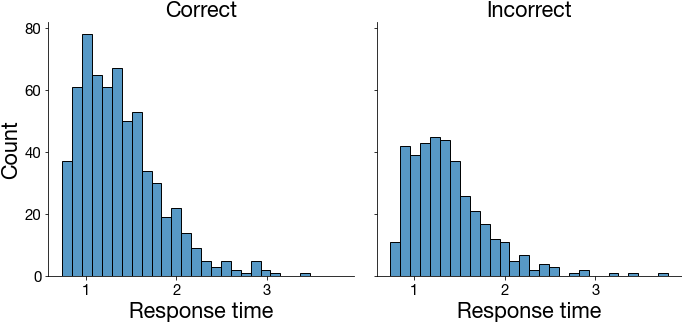

In [3]:
df = model.response_dataframe(data_mat)
g = sns.displot(
    data=df, x='Response time', col='Response', col_order=['Correct', 'Incorrect']
)
g.set_titles(col_template='{col_name}');

## Define probabilistic model

In [4]:
coords = {
    'component': ['response', 'response_time'], 
    'trial': np.arange(data_mat.shape[0]),
}
with pm.Model(coords=coords) as graph:
    x = pm.ConstantData('x', data_mat, dims=['trial', 'component'])
    
    τ_ = pm.Uniform("τ", lower=0, upper=2)
    A_ = pm.Uniform("A", lower=0, upper=10)
    b_ = pm.Uniform("b", lower=0, upper=10)
    v1_ = pm.Uniform("v1", lower=0, upper=5)
    v2_ = pm.Uniform("v2", lower=0, upper=5)
    
    response = pm.DensityDist(
        'response',
        s, 
        τ_, 
        A_, 
        b_, 
        v1_, 
        v2_,
        logp=model.logp,
        random=model.random,
        observed=x,
        dims=['trial', 'component'],
    )

## Prior predictive samples

In [5]:
with graph:
    pp = pm.sample_prior_predictive()
samples = pp.prior_predictive.stack({'sample': ['chain', 'draw']})

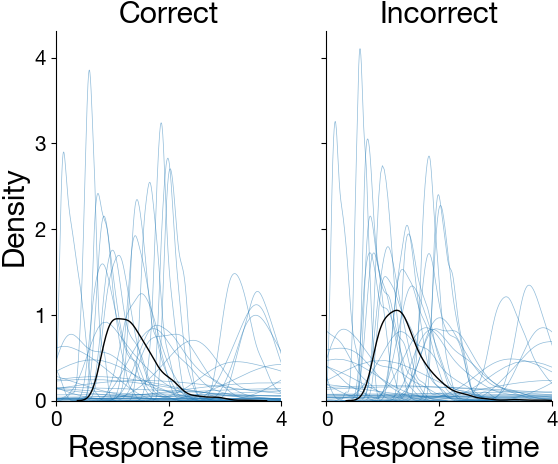

In [6]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
kwargs = {'linewidth': 0.5, 'alpha': 0.5, 'color': 'C0'}
for i in range(50):
    sample = samples.isel(sample=i)
    responses = sample.sel(component='response').response.values
    times = sample.sel(component='response_time').response.values
    sns.kdeplot(times[responses == 1], ax=ax[0], warn_singular=False, **kwargs)
    sns.kdeplot(times[responses == 0], ax=ax[1], warn_singular=False, **kwargs)

responses = pp.observed_data.sel(component='response').response.values
times = pp.observed_data.sel(component='response_time').response.values
sns.kdeplot(times[responses == 1], ax=ax[0], warn_singular=False, linewidth=1, color='k')
sns.kdeplot(times[responses == 0], ax=ax[1], warn_singular=False, linewidth=1, color='k')
ax[0].set(title='Correct', xlabel='Response time', xlim=[0, 4])
ax[1].set(title='Incorrect', xlabel='Response time', xlim=[0, 4]);

## Sample posterior distribution

In [7]:
with graph:
    trace = pm.sample(init="jitter+adapt_diag_grad", tune=1000, target_accept=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag_grad...
/Users/morton/anaconda3/envs/pymc4/lib/python3.10/site-packages/pymc/aesaraf.py:996: UserWarning: The parameter 'updates' of aesara.function() expects an OrderedDict, got <class 'dict'>. Using a standard dictionary here results in non-deterministic behavior. You should use an OrderedDict if you are using Python 2.7 (collections.OrderedDict for older python), or use a list of (shared, update) pairs. Do not just convert your dictionary to this type before the call as the conversion will still be non-deterministic.
  aesara_function = aesara.function(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [τ, A, b, v1, v2]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 223 seconds.


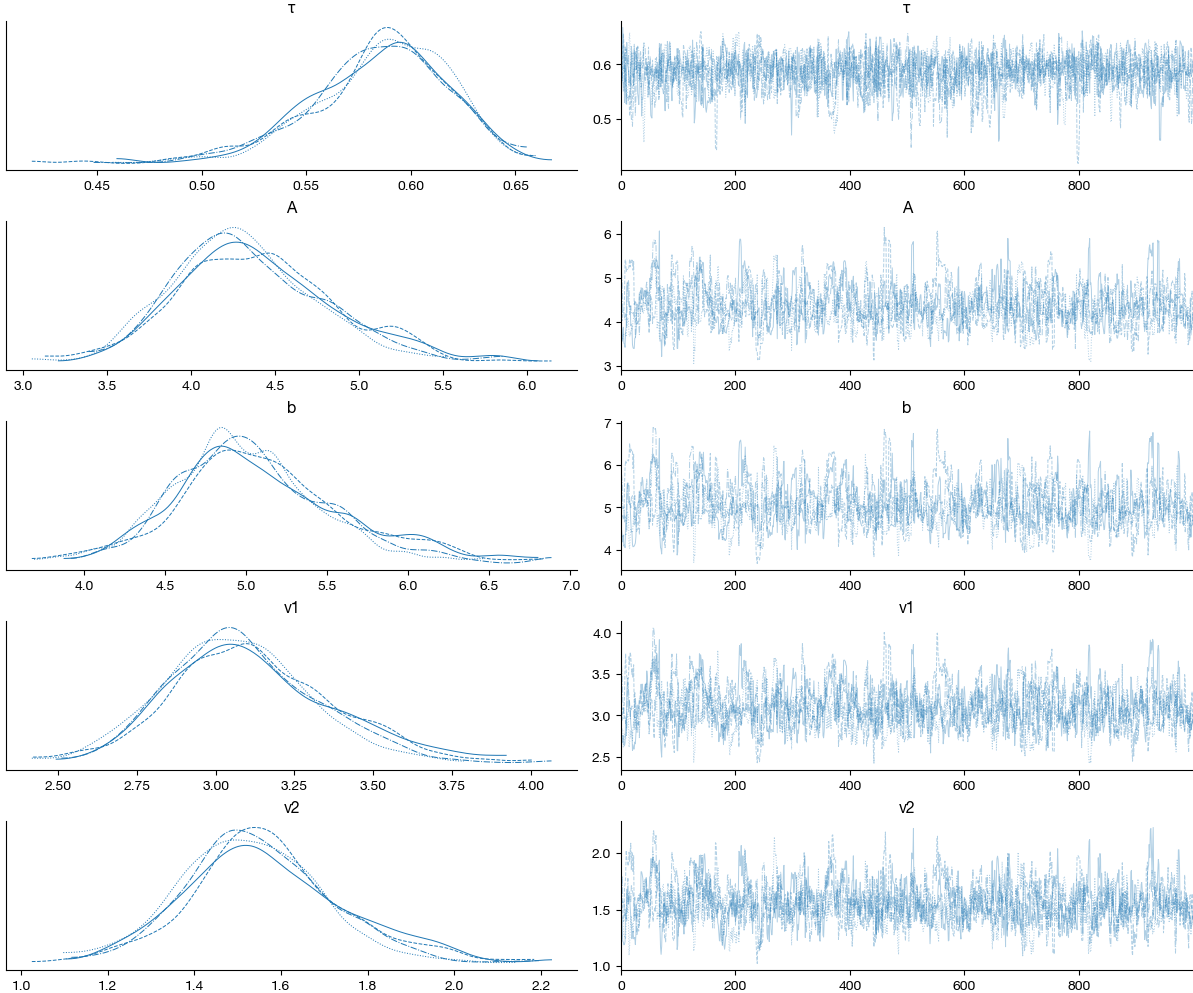

In [8]:
with mpl.rc_context({'figure.constrained_layout.use': True}):
    az.plot_trace(trace);

## Examine posterior predictive samples

In [9]:
with graph:
    pp = pm.sample_posterior_predictive(trace)
samples = pp.posterior_predictive.stack({'sample': ['chain', 'draw']})

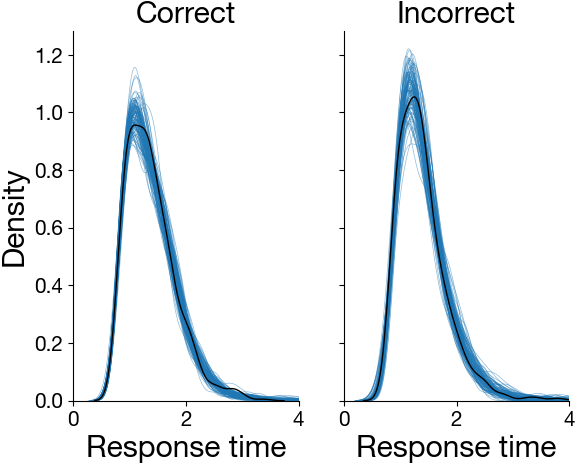

In [10]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
kwargs = {'linewidth': 0.5, 'alpha': 0.5, 'color': 'C0'}
for i in range(100):
    sample = samples.isel(sample=i)
    responses = sample.sel(component='response').response.values
    times = sample.sel(component='response_time').response.values
    sns.kdeplot(times[responses == 1], ax=ax[0], warn_singular=False, **kwargs)
    sns.kdeplot(times[responses == 0], ax=ax[1], warn_singular=False, **kwargs)

responses = pp.observed_data.sel(component='response').response.values
times = pp.observed_data.sel(component='response_time').response.values
sns.kdeplot(times[responses == 1], ax=ax[0], warn_singular=False, linewidth=1, color='k')
sns.kdeplot(times[responses == 0], ax=ax[1], warn_singular=False, linewidth=1, color='k')
ax[0].set(title='Correct', xlabel='Response time', xlim=[0, 4])
ax[1].set(title='Incorrect', xlabel='Response time', xlim=[0, 4]);

In [11]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.4
IPython version      : 8.3.0

scipy     : 1.7.3
numpy     : 1.22.1
pandas    : 1.4.2
seaborn   : 0.11.2
pymc      : 4.0.0b5
arviz     : 0.12.1
devreact  : 0.1.0
matplotlib: 3.5.2

